In [384]:
from matplotlib import pyplot as plt
from microsync.microsync import SyncDevice
import pandas as pd
from plotnine import *

In [2]:
import pyvisa
TEK_VID_PID="0x0699::0x0365"

rc = pyvisa.ResourceManager()

for r in rc.list_resources_info():
    if TEK_VID_PID in r:
        scope = rc.open_resource(r)

In [3]:
from microsync.tektronix import TDS2004

In [400]:
sd.set_pin("D99", 1)

In [389]:
sd.start_ALEX_acq(exp_time=50_000, N_bursts=1000000, burst_period=500_000)

In [ ]:
import serial

p = serial.Serial(baudrate=115200)
p.port = "COM4"
p.dtr = False
p.open()




In [441]:
p.read_all()

b''

In [401]:
#tek = TDS2004(scope)
sd = SyncDevice("COM4")

In [433]:
sd.com.close()
sd.com.dtr = False

In [434]:
sd.com.open()

In [436]:
sd.get_property(0)

'2.6.0'

In [192]:
us = 1e-6
ms = 1e-3

In [6]:
tek.hscale = 10*us
tek.hpos = 30*us

## High-speed ALEX acquisition, 2-channels

We set the time delay for shutter to 100us, and camera readout time to 200us.

In [370]:
M = 1000  # time magnification factor

In [ ]:
# Configure the oscilloscope
# Setup channel 1
tek.io.write("select:ch1 on") # camera channel
tek.io.write("ch1:probe 1") # camera channel via BNC cable
tek.ch[1].scale = 1 # V/div
tek.ch[1].position = -3 # V

# Setup channel 2
tek.io.write("select:ch2 on") # Cy3 channel
tek.io.write("ch2:probe 10")
tek.ch[2].scale = 1 # V/div
tek.ch[2].position = -2.1 # V

# Setup channel 3
tek.io.write("select:ch3 on") # Cy5 channel
tek.io.write("ch3:probe 10")
tek.ch[3].scale = 1 # V/div
tek.ch[3].position = -1.9 # V

# Setup channel 4
tek.io.write("select:ch4 on") # Cy5 channel
tek.io.write("ch4:probe 10")
tek.ch[4].scale = 1 # V/div
tek.ch[4].position = -1.7 # V

# Horizontal setup
tek.trig.source = 'CH2'  # Cy3
tek.trig.level = 2.8
tek.hscale = 25*ms/M
tek.hpos = 95*ms/M

tek.trig.mode = 'NORM'
tek.acq.stopafter = 'RUNSTOP'
tek.acq.run()

In [372]:
# Configure sync device
sd.clear()
sd.selected_lasers=0b1110
sd.interlock_enabled = False
sd.cam_level_trigger_mode = 1
sd.cam_readout_us = int(12_000 / M)
sd.shutter_delay_us = int(1_000 / M)

In [373]:
exp = int(10_000/M)
tb = "us" if exp < 500 else "ms"

df = pd.DataFrame()
tek.update_preamble()
tek.io.write("data:stop 1300")
sd.start_ALEX_acq(exp_time=exp, N_bursts=1000000, burst_period=20*exp + 10_000)
for i in range(3):
    _ = tek.read_curves_df([1, 2, 3, 4]).iloc[0:-1:2, :]  # pick every Nth point
    _['rep'] = i
    df = pd.concat([df, _])

sd.clear()

df = (df
    .rename(columns={'CH1': 'camera', 'CH2': 'Cy3', 'CH3': 'Cy5', 'CH4': 'Cy7'})
    .melt(id_vars=['time', 'rep'], var_name='channel', value_name='voltage')
    .assign(time=lambda df: df.time * (1000 if tb == 'ms' else 1000_000))
    .assign(line = lambda df: df.channel + '.' + df.rep.astype(str)))
df.to_parquet(f'data/{int(5000/M)}us_ALEX_jitter.parquet')

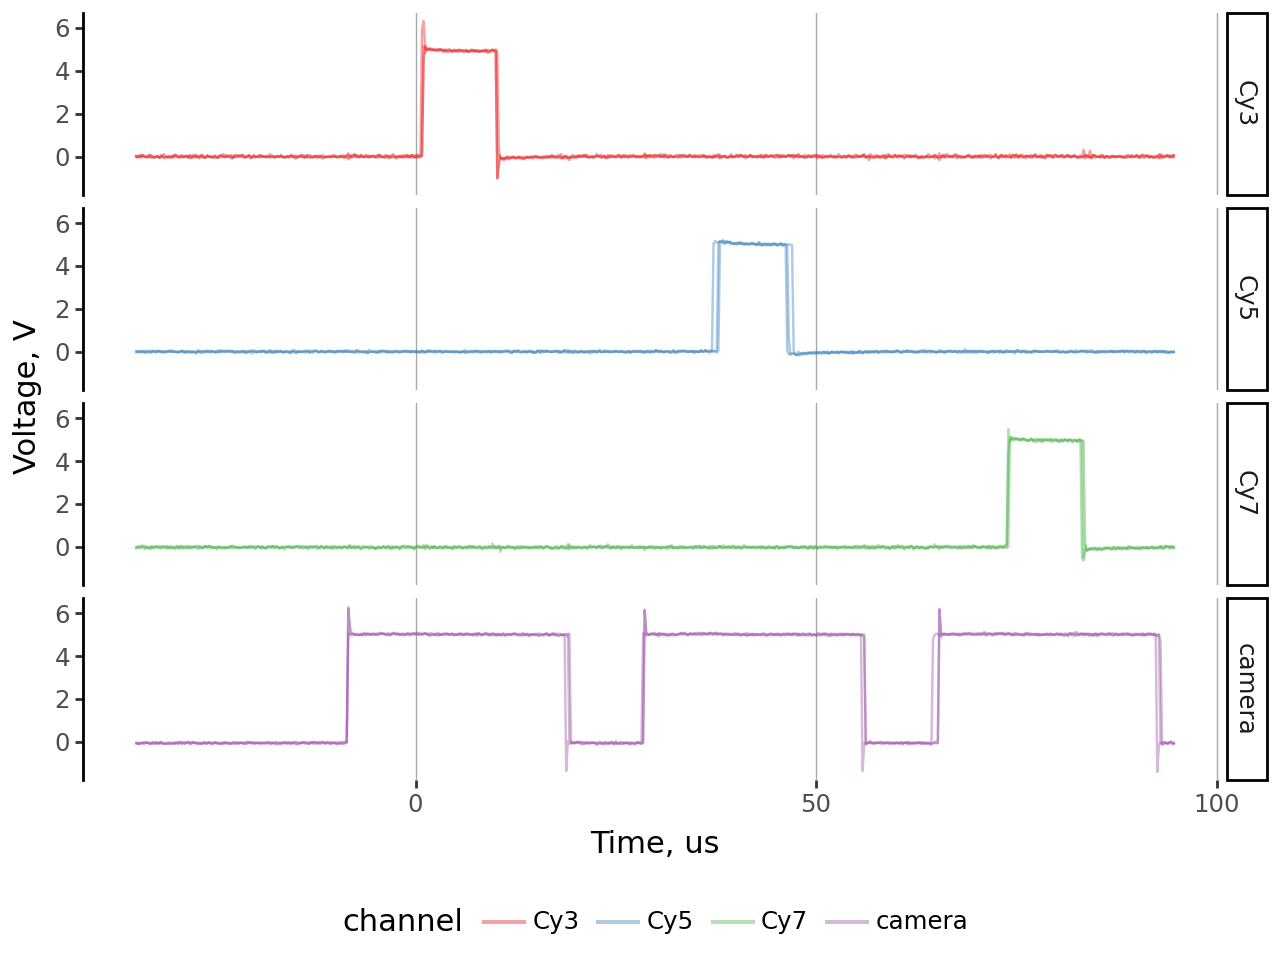

In [374]:
p = (ggplot(df, #df.assign(voltage = lambda df: df.voltage + df.offset),
    aes(x='time', y='voltage', color='channel', group="line"))
    + geom_line(alpha=0.4)
    + scale_color_brewer(type='qual', palette='Set1')
    + xlab(f"Time, {tb}")
    + ylab("Voltage, V")
    + theme_classic()
    + theme(legend_position='bottom', axis_line_x = element_blank(), panel_grid_major_x= element_line(color = "darkgrey", linetype = "solid", size = 0.5))
    + facet_grid('channel ~ .')
    )
p

In [361]:
ggsave(p, f"data/{exp}us_ALEX_jitter.png", width=8, height=8, dpi=300)

C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:610: PlotnineWarning: Saving 8 x 8 in image.
C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:611: PlotnineWarning: Filename: data/10us_ALEX_jitter.png


In [381]:
## Run the test multiple times
N = 100
Ms = [1, 10, 100, 500, 1000]
tek.io.write("data:stop 1300")

# Configure the oscilloscope
# Setup channel 1
tek.io.write("select:ch1 on") # camera channel
tek.io.write("ch1:probe 1") # camera channel via BNC cable
tek.ch[1].scale = 1 # V/div
tek.ch[1].position = -3 # V

# Setup channel 2
tek.io.write("select:ch2 on") # Cy3 channel
tek.io.write("ch2:probe 10")
tek.ch[2].scale = 1 # V/div
tek.ch[2].position = -2.1 # V

# Setup channel 3
tek.io.write("select:ch3 on") # Cy5 channel
tek.io.write("ch3:probe 10")
tek.ch[3].scale = 1 # V/div
tek.ch[3].position = -1.9 # V

# Setup channel 4
tek.io.write("select:ch4 on") # Cy5 channel
tek.io.write("ch4:probe 10")
tek.ch[4].scale = 1 # V/div
tek.ch[4].position = -1.7 # V

tek.trig.mode = 'NORM'
tek.acq.stopafter = 'RUNSTOP'


for M in Ms:
    # Horizontal oscilloscope setup
    tek.trig.source = 'CH2'  # Cy3
    tek.trig.level = 2.8
    tek.hscale = 25*ms/M
    tek.hpos = 100*ms/M

    tek.acq.run()

    # Configure sync device
    sd.clear()
    sd.selected_lasers=0b1110
    sd.interlock_enabled = False
    sd.cam_level_trigger_mode = 1
    sd.cam_readout_us = int(12_000 / M)
    sd.shutter_delay_us = int(1_000 / M)

    exp = int(10_000/M)
    tb = "us" if exp < 500 else "ms"

    df = pd.DataFrame()
    tek.update_preamble()
    sd.start_ALEX_acq(exp_time=exp, N_bursts=1000000, burst_period=20*exp + 10_000)
    for i in range(N):
        _ = tek.read_curves_df([1, 2, 3, 4])
        _['rep'] = i
        df = pd.concat([df, _])

    sd.clear()

    df = (df
        .rename(columns={'CH1': 'camera', 'CH2': 'Cy3', 'CH3': 'Cy5', 'CH4': 'Cy7'})
        .melt(id_vars=['time', 'rep'], var_name='channel', value_name='voltage')
        .assign(time=lambda df: df.time * (1000 if tb == 'ms' else 1000_000))
        .assign(line = lambda df: df.channel + '.' + df.rep.astype(str)))
    df.to_parquet(f'data/{exp}us_ALEX_jitter.parquet')

    p = (ggplot(df, #df.assign(voltage = lambda df: df.voltage + df.offset),
    aes(x='time', y='voltage', color='channel', group="line"))
    + geom_line(alpha=0.4)
    + scale_color_brewer(type='qual', palette='Set1')
    + xlab(f"Time, {tb}")
    + ylab("Voltage, V")
    + theme_classic()
    + theme(legend_position='bottom', axis_line_x = element_blank(), panel_grid_major_x= element_line(color = "darkgrey", linetype = "solid", size = 0.5))
    + facet_grid('channel ~ .')
    )
    ggsave(p, f"data/{exp}us_ALEX_jitter.png", width=8, height=8, dpi=300)

C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:610: PlotnineWarning: Saving 8 x 8 in image.
C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:611: PlotnineWarning: Filename: data/10000us_ALEX_jitter.png
C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:610: PlotnineWarning: Saving 8 x 8 in image.
C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:611: PlotnineWarning: Filename: data/1000us_ALEX_jitter.png
C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:610: PlotnineWarning: Saving 8 x 8 in image.
C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:611: PlotnineWarning: Filename: data/100us_ALEX_jitter.png
C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:610: PlotnineWarning: Saving 8 x 8 in image.
C:\Users\rkiselev\AppData\Roaming\Python\Python312\s

In [383]:
## Run the test multiple times
N = 1000
Ms = [1000] # [1, 10, 100, 500, 1000]
tek.io.write("data:stop 1300")

# Configure the oscilloscope
# Setup channel 1
tek.io.write("select:ch1 on") # camera channel
tek.io.write("ch1:probe 1") # camera channel via BNC cable
tek.ch[1].scale = 1 # V/div
tek.ch[1].position = -3 # V

# Setup channel 2
tek.io.write("select:ch2 on") # Cy3 channel
tek.io.write("ch2:probe 10")
tek.ch[2].scale = 1 # V/div
tek.ch[2].position = -2.1 # V

# Setup channel 3
tek.io.write("select:ch3 on") # Cy5 channel
tek.io.write("ch3:probe 10")
tek.ch[3].scale = 1 # V/div
tek.ch[3].position = -1.9 # V

# Setup channel 4
tek.io.write("select:ch4 on") # Cy5 channel
tek.io.write("ch4:probe 10")
tek.ch[4].scale = 1 # V/div
tek.ch[4].position = -1.7 # V

tek.trig.mode = 'NORM'
tek.acq.stopafter = 'RUNSTOP'


for M in Ms:
    # Horizontal oscilloscope setup
    tek.trig.source = 'CH2'  # Cy3
    tek.trig.level = 2.8
    tek.hscale = 25*ms/M
    tek.hpos = 100*ms/M

    tek.acq.run()

    # Configure sync device
    sd.clear()
    sd.selected_lasers=0b1110
    sd.interlock_enabled = False
    sd.cam_level_trigger_mode = 1
    sd.cam_readout_us = int(12_000 / M)
    sd.shutter_delay_us = int(1_000 / M)

    exp = int(10_000/M)
    tb = "us" if exp < 500 else "ms"

    df = pd.DataFrame()
    tek.update_preamble()
    sd.start_ALEX_acq(exp_time=exp, N_bursts=1000000, burst_period=20*exp + 10_000)
    for i in range(N):
        _ = tek.read_curves_df([1, 2, 3, 4])
        _['rep'] = i
        df = pd.concat([df, _])

    sd.clear()

    df = (df
        .rename(columns={'CH1': 'camera', 'CH2': 'Cy3', 'CH3': 'Cy5', 'CH4': 'Cy7'})
        .melt(id_vars=['time', 'rep'], var_name='channel', value_name='voltage')
        .assign(time=lambda df: df.time * (1000 if tb == 'ms' else 1000_000))
        .assign(line = lambda df: df.channel + '.' + df.rep.astype(str)))
    df.to_parquet(f'data1000/{exp}us_ALEX_jitter.parquet')

    p = (ggplot(df, #df.assign(voltage = lambda df: df.voltage + df.offset),
    aes(x='time', y='voltage', color='channel', group="line"))
    + geom_line(alpha=0.4)
    + scale_color_brewer(type='qual', palette='Set1')
    + xlab(f"Time, {tb}")
    + ylab("Voltage, V")
    + theme_classic()
    + theme(legend_position='bottom', axis_line_x = element_blank(), panel_grid_major_x= element_line(color = "darkgrey", linetype = "solid", size = 0.5))
    + facet_grid('channel ~ .')
    )
    ggsave(p, f"data1000/{exp}us_ALEX_jitter.png", width=8, height=8, dpi=300)

C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:610: PlotnineWarning: Saving 8 x 8 in image.
C:\Users\rkiselev\AppData\Roaming\Python\Python312\site-packages\plotnine\ggplot.py:611: PlotnineWarning: Filename: data1000/10us_ALEX_jitter.png
